# Text Similarity and Semantic Search

## Overview

Text similarity measures how alike two pieces of text are. It underpins document deduplication, semantic search, clustering, and recommendation. The right similarity method depends on whether you need lexical overlap or semantic meaning.

**Similarity approaches:**

| Method | Captures | Speed | When to use |
|---|---|---|---|
| Jaccard | Exact word overlap | Fast | Deduplication |
| Cosine (TF-IDF) | Vocabulary overlap | Fast | Keyword search |
| BM25 | Vocabulary + frequency | Fast | Information retrieval |
| Cosine (embeddings) | Semantic meaning | Medium | Semantic search |
| Cross-encoder | Full semantic context | Slow | Re-ranking |

**Semantic search pipeline:**
```
Corpus → Embed all documents → Store vectors
Query  → Embed query        → Find nearest neighbours
```

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.decomposition import TruncatedSVD

rng = np.random.default_rng(42)
# Ecological monitoring report corpus
corpus = [
    "Nitrate levels elevated at site NORTH-04 following heavy rainfall event.",
    "Phosphorus concentration exceeded threshold at upstream monitoring station.",
    "Species richness increased after riparian vegetation restoration project.",
    "Water quality improved substantially following buffer strip installation.",
    "Macroinvertebrate communities recovering to reference condition after restoration.",
    "Dissolved oxygen levels dropped critically low in lower catchment reach.",
    "Agricultural runoff detected; nutrient loading increased during autumn period.",
    "EPT richness doubled within two seasons of wetland restoration work.",
    "Fish passage restored after culvert replacement; salmon populations returning.",
    "pH dropped below acceptable range indicating continued acidification stress.",
    "Biodiversity indices show significant positive trend at restored sites.",
    "Turbidity spike detected following upstream construction activity.",
]
print(f"Corpus: {len(corpus)} documents")
for i, doc in enumerate(corpus):
    print(f"  Doc {i:2d}: {doc[:60]}...")

Corpus: 12 documents
  Doc  0: Nitrate levels elevated at site NORTH-04 following heavy rai...
  Doc  1: Phosphorus concentration exceeded threshold at upstream moni...
  Doc  2: Species richness increased after riparian vegetation restora...
  Doc  3: Water quality improved substantially following buffer strip ...
  Doc  4: Macroinvertebrate communities recovering to reference condit...
  Doc  5: Dissolved oxygen levels dropped critically low in lower catc...
  Doc  6: Agricultural runoff detected; nutrient loading increased dur...
  Doc  7: EPT richness doubled within two seasons of wetland restorati...
  Doc  8: Fish passage restored after culvert replacement; salmon popu...
  Doc  9: pH dropped below acceptable range indicating continued acidi...
  Doc 10: Biodiversity indices show significant positive trend at rest...
  Doc 11: Turbidity spike detected following upstream construction act...


---
## Jaccard and TF-IDF Cosine Similarity

In [2]:
# Jaccard similarity: intersection over union of word sets
def jaccard_similarity(text1, text2):
    set1 = set(text1.lower().split())
    set2 = set(text2.lower().split())
    return len(set1 & set2) / len(set1 | set2)

# TF-IDF cosine similarity
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1,2))
X = tfidf.fit_transform(corpus)
cos_sim = cosine_similarity(X)

# Query: find most similar documents to a query
query = "water quality improvement after restoration"
query_vec = tfidf.transform([query])
scores = cosine_similarity(query_vec, X).ravel()
ranked = np.argsort(scores)[::-1]
print(f"Query: '{query}'")
print("\nTop 5 most similar documents (TF-IDF cosine):")
for rank, idx in enumerate(ranked[:5]):
    print(f"  {rank+1}. [score={scores[idx]:.3f}] {corpus[idx][:65]}...")

# Jaccard comparison
jac_scores = [jaccard_similarity(query, doc) for doc in corpus]
jac_ranked = np.argsort(jac_scores)[::-1]
print("\nTop 3 (Jaccard):")
for idx in jac_ranked[:3]:
    print(f"  [score={jac_scores[idx]:.3f}] {corpus[idx][:65]}...")

Query: 'water quality improvement after restoration'

Top 5 most similar documents (TF-IDF cosine):
  1. [score=0.416] Water quality improved substantially following buffer strip insta...
  2. [score=0.094] Macroinvertebrate communities recovering to reference condition a...
  3. [score=0.088] Species richness increased after riparian vegetation restoration ...
  4. [score=0.087] EPT richness doubled within two seasons of wetland restoration wo...
  5. [score=0.000] Fish passage restored after culvert replacement; salmon populatio...

Top 3 (Jaccard):
  [score=0.182] Water quality improved substantially following buffer strip insta...
  [score=0.182] Species richness increased after riparian vegetation restoration ...
  [score=0.083] Macroinvertebrate communities recovering to reference condition a...


---
## Similarity Matrix Heatmap

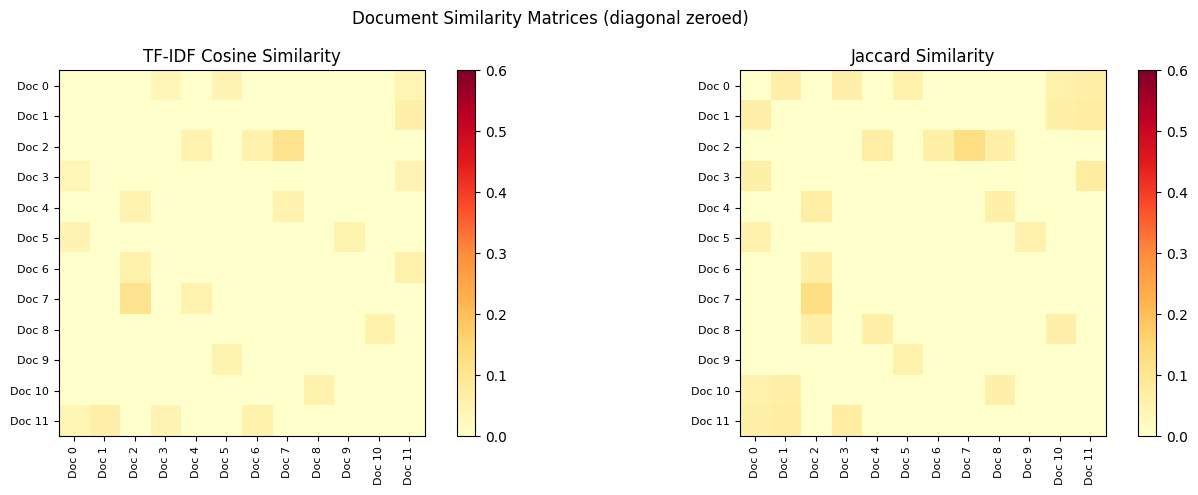

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
short_labels = [f"Doc {i}" for i in range(len(corpus))]
for ax, sim_matrix, title in [
        (axes[0], cos_sim, 'TF-IDF Cosine Similarity'),
        (axes[1], np.array([[jaccard_similarity(corpus[i], corpus[j])
                              for j in range(len(corpus))]
                             for i in range(len(corpus))]),
         'Jaccard Similarity')]:
    np.fill_diagonal(sim_matrix, 0)  # zero diagonal for visibility
    im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=0.6)
    ax.set_xticks(range(len(corpus)))
    ax.set_yticks(range(len(corpus)))
    ax.set_xticklabels(short_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(short_labels, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle('Document Similarity Matrices (diagonal zeroed)')
plt.tight_layout(); plt.show()

---
## Latent Semantic Analysis (LSA)

In [4]:
# LSA: SVD on TF-IDF matrix -> dense semantic space
svd = TruncatedSVD(n_components=4, random_state=42)
X_lsa = svd.fit_transform(X)
print(f"LSA: {X.shape} -> {X_lsa.shape}")
print(f"Variance explained by 4 components: {svd.explained_variance_ratio_.sum():.1%}")
# Semantic search in LSA space
query_lsa = svd.transform(query_vec)
lsa_scores = cosine_similarity(query_lsa, X_lsa).ravel()
lsa_ranked = np.argsort(lsa_scores)[::-1]
print(f"\nLSA search for: '{query}'")
print("Top 5 results:")
for rank, idx in enumerate(lsa_ranked[:5]):
    print(f"  {rank+1}. [score={lsa_scores[idx]:.3f}] {corpus[idx][:65]}...")
# Document clustering in LSA space
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km.fit_predict(X_lsa)
print("\nDocument clusters (LSA + KMeans k=3):")
for cluster_id in range(3):
    members = [i for i, c in enumerate(clusters) if c == cluster_id]
    print(f"  Cluster {cluster_id}: docs {members}")
    for idx in members:
        print(f"    - {corpus[idx][:60]}...")

LSA: (12, 161) -> (12, 4)
Variance explained by 4 components: 30.5%

LSA search for: 'water quality improvement after restoration'
Top 5 results:
  1. [score=0.812] Agricultural runoff detected; nutrient loading increased during a...
  2. [score=0.704] Water quality improved substantially following buffer strip insta...
  3. [score=0.685] Turbidity spike detected following upstream construction activity...
  4. [score=0.683] Species richness increased after riparian vegetation restoration ...
  5. [score=0.617] Nitrate levels elevated at site NORTH-04 following heavy rainfall...

Document clusters (LSA + KMeans k=3):
  Cluster 0: docs [2, 4, 7]
    - Species richness increased after riparian vegetation restora...
    - Macroinvertebrate communities recovering to reference condit...
    - EPT richness doubled within two seasons of wetland restorati...
  Cluster 1: docs [0, 1, 3, 5, 6, 9, 11]
    - Nitrate levels elevated at site NORTH-04 following heavy rai...
    - Phosphorus concentra

In [5]:
# Sentence embeddings for semantic similarity (using sklearn as proxy)
# Real-world: use sentence-transformers library for state-of-the-art embeddings
# Here: demonstrate the pattern with TF-IDF + SVD as a lightweight proxy
def embed_texts(texts, vectorizer, svd_model):
    return svd_model.transform(vectorizer.transform(texts))

queries = [
    "poor water quality nutrient pollution",
    "ecological recovery biodiversity improvement",
    "fish and wildlife habitat restoration",
]
print("Semantic search with LSA embeddings:")
for q in queries:
    q_vec = embed_texts([q], tfidf, svd)
    scores = cosine_similarity(q_vec, X_lsa).ravel()
    top_idx = np.argsort(scores)[::-1][0]
    print(f"\nQuery: '{q}'")
    print(f"  Best match [score={scores[top_idx]:.3f}]: {corpus[top_idx]}")
print("\nFor production semantic search:")
print("  pip install sentence-transformers")
print("  from sentence_transformers import SentenceTransformer")
print("  model = SentenceTransformer('all-MiniLM-L6-v2')")
print("  embeddings = model.encode(corpus)")
print("  cosine_similarity(model.encode([query]), embeddings)")

Semantic search with LSA embeddings:

Query: 'poor water quality nutrient pollution'
  Best match [score=0.975]: Water quality improved substantially following buffer strip installation.

Query: 'ecological recovery biodiversity improvement'
  Best match [score=1.000]: Biodiversity indices show significant positive trend at restored sites.

Query: 'fish and wildlife habitat restoration'
  Best match [score=0.824]: EPT richness doubled within two seasons of wetland restoration work.

For production semantic search:
  pip install sentence-transformers
  from sentence_transformers import SentenceTransformer
  model = SentenceTransformer('all-MiniLM-L6-v2')
  embeddings = model.encode(corpus)
  cosine_similarity(model.encode([query]), embeddings)


---

## Common Pitfalls

**1. Using TF-IDF cosine similarity for semantic search**  
TF-IDF cosine similarity measures vocabulary overlap, not meaning. "water quality deteriorated" and "aquatic ecosystem degraded" have zero TF-IDF similarity despite being semantically equivalent. Use sentence embeddings (sentence-transformers) for semantic search.

**2. Not normalising TF-IDF vectors before computing cosine similarity**  
Cosine similarity assumes unit-normalised vectors. `sklearn.metrics.pairwise.cosine_similarity()` normalises internally, but if you compute dot products manually (`X @ X.T`), unnormalised vectors give incorrect results — longer documents appear more similar to everything.

**3. Using all-pairs cosine similarity on a large corpus**  
Computing a full n × n similarity matrix is O(n²) in memory and time. For n = 100,000 documents, this requires ~80 GB at float64. Use approximate nearest neighbour search (FAISS, Annoy, hnswlib) for large-scale similarity search.

**4. Treating LSA components as interpretable topics**  
LSA components are mathematical constructs (singular vectors), not human-interpretable topics. A negative loading is meaningful in LSA but confusing to interpret as a topic. For interpretable topics, use LDA or NMF instead.

**5. Not re-embedding the query using the same vectoriser fitted on the corpus**  
The query must be transformed using the exact same fitted `TfidfVectorizer` and `TruncatedSVD` objects used to embed the corpus. Fitting a new vectoriser on the query alone produces a different vocabulary and incomparable vectors — the similarity scores will be meaningless.

---
*python_methods_library - Samantha McGarrigle*